In [26]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import matplotlib.pyplot as plt
import pandas as pd
import utils_funs


def load_data(folder_path):
    reviews = []
    labels = []
    for label in ['pos', 'neg']:
        dir_path = os.path.join(folder_path, label)
        for filename in os.listdir(dir_path):
            filepath = os.path.join(dir_path, filename)
            with open(filepath, 'r', encoding='utf-8') as f:
                reviews.append(f.read())
            labels.append(1 if label == 'pos' else 0)

    df = pd.DataFrame({'review': reviews, 'label': labels})
    return df

train_df = load_data('../data/IMDB/train')
test_df  = load_data('../data/IMDB/test')

train_df.head()


,review,label
0,"This isn't the comedic Robin Williams, nor is ...",1
1,Yes its an art... to successfully make a slow ...,1
2,I absolutely LOVED this film! I do not at all ...,1
3,Somewhat funny and well-paced action thriller ...,1
4,"Sure, Titanic was a good movie, the first time...",1


# Text Preprocessing

In [27]:
import string

def preprocess_text(text):
    text = text.lower()
    text = text.replace("<br />", " ")
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    return tokens

train_df['tokens'] = train_df['review'].apply(preprocess_text)
test_df['tokens'] = test_df['review'].apply(preprocess_text)

train_df.head()

,review,label,tokens
0,"This isn't the comedic Robin Williams, nor is ...",1,"[this, isnt, the, comedic, robin, williams, no..."
1,Yes its an art... to successfully make a slow ...,1,"[yes, its, an, art, to, successfully, make, a,..."
2,I absolutely LOVED this film! I do not at all ...,1,"[i, absolutely, loved, this, film, i, do, not,..."
3,Somewhat funny and well-paced action thriller ...,1,"[somewhat, funny, and, wellpaced, action, thri..."
4,"Sure, Titanic was a good movie, the first time...",1,"[sure, titanic, was, a, good, movie, the, firs..."


# Build Vocabulary

In [28]:
def build_vocabulary(tokens_series):
    vocab = {}
    index = 0
    for tokens in tokens_series:
        for word in tokens:
            if word not in vocab:
                vocab[word] = index
                index += 1
    return vocab

vocab = build_vocabulary(train_df['tokens'])
print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 49870


# Bag of Words

In [29]:
import numpy as np

def build_bow_matrix(tokens_series, vocab):
    tokens_list = list(tokens_series)
    matrix = np.zeros((len(tokens_list), len(vocab)), dtype=np.int16)
    for i, tokens in enumerate(tokens_list):
        for word in tokens:
            if word in vocab:
                matrix[i][vocab[word]] += 1
    return matrix


train_bow = build_bow_matrix(train_df['tokens'], vocab)
test_bow  = build_bow_matrix(test_df['tokens'], vocab)

# Class Priors

In [30]:
def compute_prior(df):
    total = len(df)
    priors = {}
    priors[1] = len(df[df['label'] == 1]) / total
    priors[0] = len(df[df['label'] == 0]) / total
    return priors

priors = compute_prior(train_df)
print(f"P(positive) = {priors[1]}")
print(f"P(negative) = {priors[0]}")

P(positive) = 0.4939892731644165
P(negative) = 0.5060107268355835


# Word Probabilities with Laplace Smoothing

In [31]:
def compute_word_prob(labels, vocab, train_bow):
    word_prob = {}

    for cls in set(labels):
        cls_indices = []
        for i in range(len(labels)):
            if labels[i] == cls:
                cls_indices.append(i)

        cls_bow = train_bow[cls_indices]
        word_count = cls_bow.sum(axis=0)
        total_words = word_count.sum()
        word_prob[cls] = (word_count + 1) / (total_words + len(vocab))

    return word_prob

word_prob = compute_word_prob(train_df['label'].tolist(), vocab, train_bow)

In [32]:
def predict(bow_matrix, word_prob, priors, with_log):
    predictions = []

    for row in bow_matrix:
        cls_scores = {}
        for cls in priors:
            if with_log:
                score = (np.log(priors[cls])
                         + np.sum(np.log(word_prob[cls]) * row))
            else:
                score = (priors[cls]
                         * np.prod(word_prob[cls] ** row))

            cls_scores[cls] = score

        predictions.append(max(cls_scores, key=cls_scores.get))

    return predictions


In [39]:
# with log
y_pred_log = predict(test_bow, word_prob, priors, with_log=True)
acc_log = utils_funs.compute_accuracy(test_df['label'].tolist(), y_pred_log)

# without log
y_pred = predict(test_bow, word_prob, priors, with_log=False)
acc = utils_funs.compute_accuracy(test_df['label'].tolist(), y_pred)

results = pd.DataFrame({
    'Method': ['With Log Probabilities', 'Without Log Probabilities'],
    'Accuracy': [acc_log, acc]
})

print(results)

                      Method  Accuracy
0     With Log Probabilities       0.0
1  Without Log Probabilities       0.0


# Top 20 Most Frequent Words

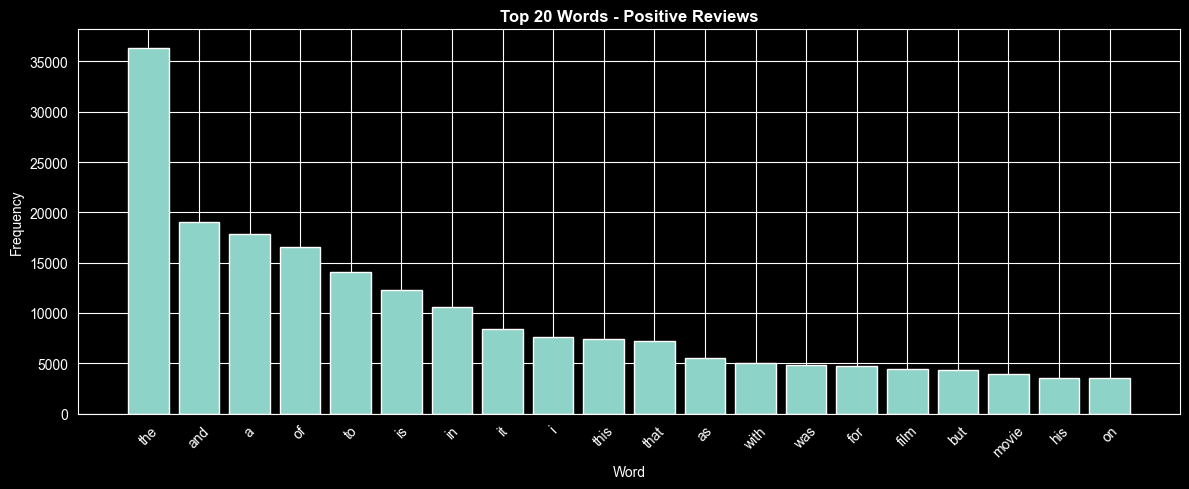

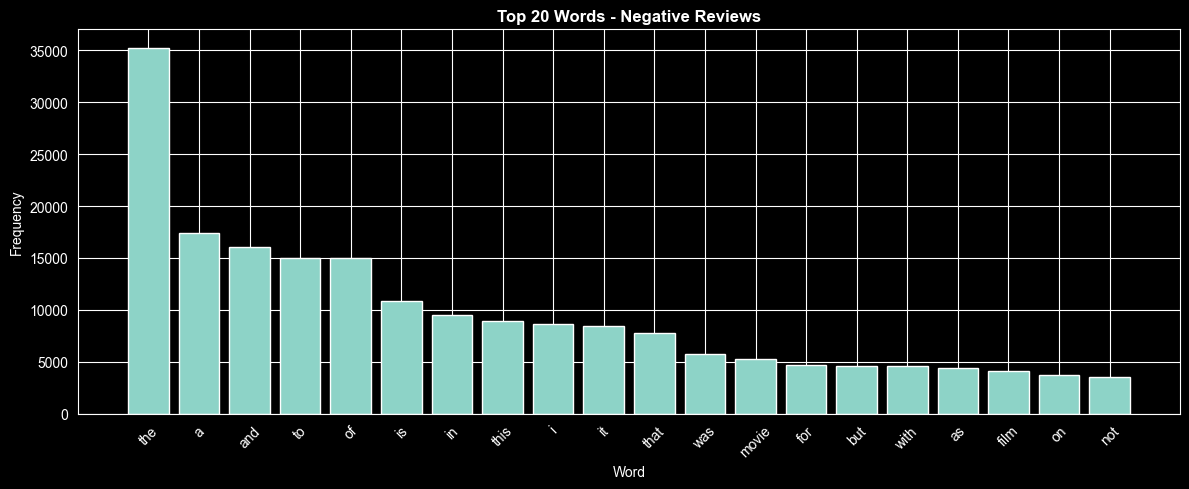

In [42]:
from collections import defaultdict

pos_counts = defaultdict(int)
neg_counts = defaultdict(int)

for i in range(len(train_df)):
    words = train_df['tokens'][i]
    label = train_df['label'][i]

    if label == 1:
        for word in words:
            pos_counts[word] += 1
    else:
        for word in words:
            neg_counts[word] += 1

# get top 20 for each
top_pos = sorted(pos_counts.items(), key=lambda x: x[1], reverse=True)[:20]
top_neg = sorted(neg_counts.items(), key=lambda x: x[1], reverse=True)[:20]

# separate words & counts
pos_words = []
pos_counts_vals = []
for word, count in top_pos:
    pos_words.append(word)
    pos_counts_vals.append(count)

neg_words = []
neg_counts_vals = []
for word, count in top_neg:
    neg_words.append(word)
    neg_counts_vals.append(count)

# plot pos
plt.figure(figsize=(12, 5))
plt.bar(pos_words, pos_counts_vals)
plt.title('Top 20 Words - Positive Reviews', fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot neg
plt.figure(figsize=(12, 5))
plt.bar(neg_words, neg_counts_vals)
plt.title('Top 20 Words - Negative Reviews', fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()